REGRESSIONE & GS

Utilizzando il dataset Diabetes, replicare l'esercitazione pratica
    - Effettuare lo splot dei dati con test_set = 0.2 e shuffle=True
    - Effettuare la standarizzazione di train e test set
    - Allenare un SVR con kernel='linear', C=1.0, epsilon=0.1
    - Creare un griglia di parametri e avviare una Grid Search, al termine stampare i valori dei parametri e MSE
    - Risurre il dataset scalato con PCA n_components=2
    - Subplottare le rette di regressione sui dati reali del primo modello e del modello con i parametri ottimizzati

In [5]:
import numpy as np
from sklearn.svm import SVR
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV

In [6]:
data=load_diabetes()
X,y= data.data, data.target

df=pd.DataFrame(X,columns=data.feature_names)
df["target"]=y
display(df)
#df["target"].value_counts()  #ho anche valori nulli
df.groupby("target").count()  #conta i valori non nulli per colonna

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
target,,,,,,,,,,
25.0,1,1,1,1,1,1,1,1,1,1
31.0,1,1,1,1,1,1,1,1,1,1
37.0,1,1,1,1,1,1,1,1,1,1
39.0,2,2,2,2,2,2,2,2,2,2
40.0,1,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...
321.0,1,1,1,1,1,1,1,1,1,1
332.0,1,1,1,1,1,1,1,1,1,1
336.0,1,1,1,1,1,1,1,1,1,1


In [14]:
X_train,X_test,y_train,y_test=train_test_split(X,y,shuffle=True,test_size=0.2,random_state=42)

In [15]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train) #dataset di train
X_test_scaled=scaler.transform(X_test) #dataset di test

In [16]:
svr_base=SVR(kernel="linear",C=1.0, epsilon=0.1)
svr_base.fit(X_train_scaled,y_train)
y_pred_base=svr_base.predict(X_test_scaled)
mse_base=mean_squared_error(y_test,y_pred_base)

In [18]:
param_grid={"kernel":["linear"],"C":[0.1,1.0,10.0],"epsilon":[0.05,0.1,0.2]}

In [19]:
grid=GridSearchCV(SVR(),param_grid=param_grid,cv=5,scoring="neg_mean_squared_error")
grid.fit(X_train_scaled,y_train)

best_svr=grid.best_estimator_
y_pred_best=best_svr.predict(X_test_scaled)
mse_best=mean_squared_error(y_test,y_pred_best)

In [20]:
print(f"Migliori parametri:\n{grid.best_params_}")
print(f"MSE (base):\t{mse_base:.4f}")
print(f"MSE (best):\t{mse_best:.4f}")

Migliori parametri:
{'C': 1.0, 'epsilon': 0.2, 'kernel': 'linear'}
MSE (base):	2939.8128
MSE (best):	2941.8854


In [21]:
X_scaled_all=np.vstack([X_train_scaled,X_test_scaled]) #unisce verticalmente (uno sotto l'altro) due array numpy, risultato 1 dataset che contiene train+test
y_all=np.hstack([y_train,y_test])

pca=PCA(n_components=2) #faccio pca solo per la visualizzazione
X_pca=pca.fit_transform(X_scaled_all) #dataset ridotto a solo 2 componenti

In [22]:
X_pca_1=X_pca[:,0].reshape(-1,1) #reshape trasforma array 1d in una colonna 2d -1 vuol dire calcola tu il numero di righe
#senza reshap ho una lista, con rashape ho una tabella con una colonna

svr_base_1d=SVR(kernel="linear",C=1.0,epsilon=0.1) #alleno il modello
svr_base_1d.fit(X_pca_1,y_all)
y_pred_base_1d=svr_base_1d.predict(X_pca_1)

best_svr_1d=SVR(**grid.best_params_) #itera tutte le chiavi di un dizionario, prendendo solo la soluzione migliore con best_ params
best_svr_1d.fit(X_pca_1,y_all)
y_pred_best_1d=best_svr_1d.predict(X_pca_1)

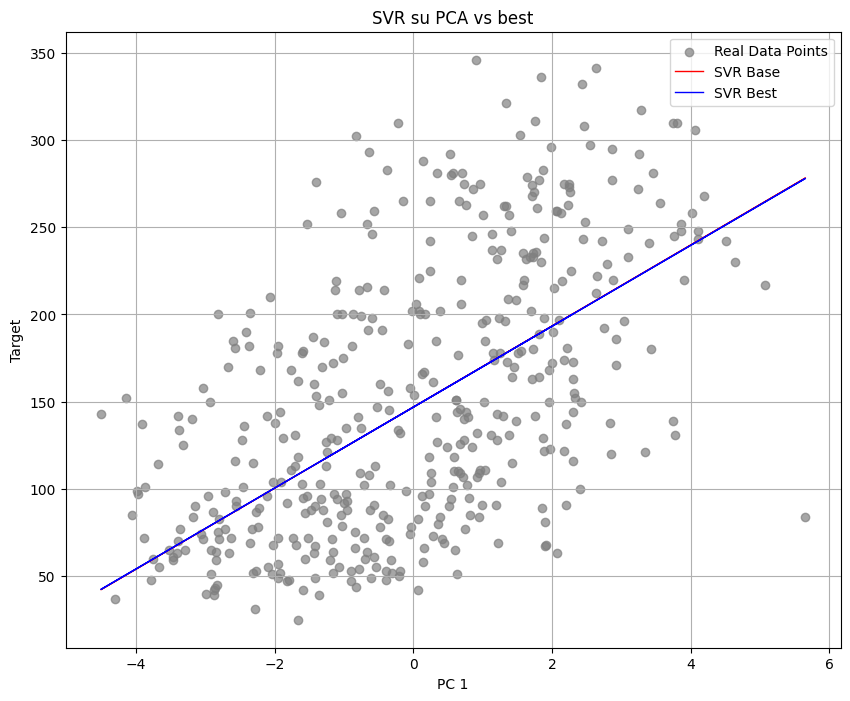

In [23]:
plt.figure(figsize=(10,8))
plt.scatter(X_pca_1,y_all,color="gray",alpha=0.7,label="Real Data Points")
plt.plot(X_pca_1,y_pred_base_1d,color="red",label="SVR Base",linewidth=1)
plt.plot(X_pca_1,y_pred_best_1d,color="blue",label="SVR Best",linewidth=1)
plt.xlabel("PC 1")
plt.ylabel("Target")
plt.title("SVR su PCA vs best")
plt.legend()
plt.grid(True)
plt.show()